# Local ROM Stability Check

Build a FOM trajectory from a chosen initial condition, construct POD/DEIM ROMs, run the true-nonlinearity ROM, and inspect capture/trajectory/modes before training a neural ROM.

In [22]:
using LinearAlgebra
using SparseArrays
using ComponentArrays
using OrdinaryDiffEq
using Plots
using Base64

### ADJUSTED: Use the same HPC reference and ROM helper path used by cluster ROM runs.
include(joinpath(@__DIR__, "..", "..", "src", "HPC", "integration_AC_hpc.jl"))
include(joinpath(@__DIR__, "..", "..", "HPC_compatibility", "hpc_common.jl"))
include(joinpath(@__DIR__, "..", "..", "src", "HPC", "ROM_opt_AC_hpc.jl"))
include(joinpath(@__DIR__, "..", "..", "src", "Visualizations", "optimization_visualizations.jl"))

[package-load] Loading LinearAlgebra
[package-load] Loaded LinearAlgebra
[package-load] Loading SparseArrays
[package-load] Loaded SparseArrays
[package-load] Loading Random
[package-load] Loaded Random
[package-load] Loading ComponentArrays
[package-load] Loaded ComponentArrays
[package-load] Loading LinearSolve
[package-load] Loaded LinearSolve
[package-load] Loading OrdinaryDiffEq
[package-load] Loaded OrdinaryDiffEq
[package-load] Loading OrdinaryDiffEqSDIRK
[package-load] Loaded OrdinaryDiffEqSDIRK
[package-load] Loading OrdinaryDiffEqLowOrderRK
[package-load] Loaded OrdinaryDiffEqLowOrderRK
[package-load] Loading SciMLSensitivity
[package-load] Loaded SciMLSensitivity
[package-load] Loading ADTypes
[package-load] Loaded ADTypes
[package-load] Loading Zygote
[package-load] Loaded Zygote
[package-load] Loading Optimization
[package-load] Loaded Optimization
[package-load] Loading OptimizationOptimisers
[package-load] Loaded OptimizationOptimisers
[package-load] Loading Optimization

visualize_FOM

## Parameters

In [23]:
N = 256
L = 1.0
ε2 = 1e-2
k = 1.0
tspan = (0.0, 2.0)
reference_dt_factor = 0.5
dimension = 1
boundary_condition = "homogeneous_dirichlet"
N_obs = 100
h = 8
seed = 1

r = 10
m = 10

u0 = nothing
initial_condition_examples = [
    (name="default", u0=nothing),
    (name="left shifted", u0=x -> tanh((x - 0.4L) / sqrt(2ε2))),
    (name="small sine", u0=x -> 0.25sin(2π * x / L)),
];

## Functions

In [24]:
### ADJUSTED: Only materialize function-valued notebook initial conditions; grid/default handling comes from HPC helpers.
function materialize_initial_condition(u0; N=256, L=1.0, ε2=1e-2, dimension=1, boundary_condition="homogeneous_dirichlet")
    dim = validate_ac_dimension(dimension)
    if isnothing(u0) || !(u0 isa Function)
        return u0
    end
    grid = ac_grid(N, L, boundary_condition)
    x = grid.x
    if dim == 1
        return Float64[u0(xi) for xi in x]
    end
    return Float64[u0(x[i], x[j]) for i in 1:N, j in 1:N]
end

function plot_initial_conditions(initial_conditions; N=256, L=1.0, ε2=1e-2, dimension=1, boundary_condition="homogeneous_dirichlet")
    grid = ac_grid(N, L, boundary_condition)
    dim = validate_ac_dimension(dimension)
    if dim == 1
        p = plot(xlabel="x", ylabel="u0", title="Initial conditions")
        for item in initial_conditions
            values = isnothing(item.u0) ? default_ac_initial_condition(N, L, ε2, dim, boundary_condition) : materialize_initial_condition(item.u0; N, L, ε2, dimension=dim, boundary_condition)
            plot!(p, grid.x, values; label=item.name)
        end
        return p
    end
    plots = Any[]
    for item in initial_conditions
        values = isnothing(item.u0) ? default_ac_initial_condition(N, L, ε2, dim, boundary_condition) : materialize_initial_condition(item.u0; N, L, ε2, dimension=dim, boundary_condition)
        push!(plots, heatmap(grid.x, grid.x, reshape(values, N, N); title=item.name, aspect_ratio=:equal))
    end
    return plot(plots...; layout=(1, length(plots)), size=(350 * length(plots), 320))
end

### ADJUSTED: Build the FOM reference through the central HPC reference builder.
function run_fom_reference(; N=256, L=1.0, ε2=1e-2, k=1.0, tspan=(0.0, 2.0), reference_dt_factor=0.5, u0=nothing, dimension=1, boundary_condition="homogeneous_dirichlet")
    tspan[1] == 0.0 || error("build_ac_reference expects tspan to start at 0.0")
    u₀ = materialize_initial_condition(u0; N, L, ε2, dimension, boundary_condition)
    ref = build_ac_reference(; N, L, ε2, k, tfinal=tspan[2], reference_dt_factor, dimension, boundary_condition, u₀)
    A = get_lap_ac_matrix(N, ε2, ref.Δx, ref.dimension, ref.boundary_condition)
    return merge(ref, (; sol=ref.u_ref, A))
end

### ADJUSTED: Build the ROM through the same HPC ROM preparation helper used by cluster training.
function build_stability_rom(fom, r::Integer, m::Integer; N_obs=100, h=8, seed=1)
    prob = prepare_ROM_optimization(fom.A, fom.u_ref, r, m; N_obs, h, seed, dimension=fom.dimension, boundary_condition=fom.boundary_condition)
    return (; prob, rom=prob.f.f.data.rom)
end

function rhs_true_rom!(du, u, p, t)
    z = p.rom.Up * u
    fz = .-p.k .* (z .^ 3 .- z)
    du .= p.rom.Ã * u + p.rom.B * fz
    return nothing
end

### ADJUSTED: Run the true-nonlinearity ROM and reconstruct it to the full state space.
function run_stability_rom(fom, rom_bundle; alg=TRBDF2())
    rom = rom_bundle.rom
    u0_rom = rom.U' * fom.u_ref.prob.u0
    p = (; rom, k=fom.u_ref.prob.p.k)
    prob = ODEProblem(rhs_true_rom!, u0_rom, fom.u_ref.prob.tspan, p)
    sol = solve(prob, alg; saveat=fom.u_ref.t)
    reconstructed = rom.U * hcat(sol.u...)
    return (; sol, reconstructed)
end

capture_ratio(s, n) = sum(abs2, s[1:min(n, length(s))]) / sum(abs2, s)

### ADJUSTED: Log state and nonlinear singular-value capture for requested m/r pairs.
function capture_table(fom; rs=[2, 4, 8, 10, 15, 20], ms=[2, 4, 8, 10, 15, 20])
    max_r = minimum((maximum(rs), length(fom.u_ref.u), length(fom.u_ref.u[1])))
    max_m = minimum((maximum(ms), length(fom.u_ref.u), length(fom.u_ref.u[1])))
    base = build_stability_rom(fom, max_r, max_m).rom
    rows = NamedTuple[]
    for r_i in rs, m_i in ms
        push!(rows, (;
            m=m_i,
            r=r_i,
            state_capture=capture_ratio(base.state_singular_values, r_i),
            nonlinear_capture=capture_ratio(base.nonlinear_singular_values, m_i),
        ))
    end
    return rows
end

### ADJUSTED: Display generated GIFs inline without relying on notebook-specific HTML bindings.
function display_stability_gif(path)
    encoded = base64encode(read(path))
    display("text/html", "<img src=\"data:image/gif;base64,$encoded\" />")
    return path
end

### ADJUSTED: Add a 2D FOM-only trajectory GIF companion to the existing 2D FOM-vs-ROM overlay helper.
function save_2d_trajectory_gif(x, y, t, U; path, title="FOM reference", max_frames=120, fps=15, clims=extrema(U))
    mkpath(dirname(path))
    frame_count = min(max_frames, length(t))
    frame_ids = unique(round.(Int, LinRange(1, length(t), frame_count)))
    anim = @animate for j in frame_ids
        heatmap(x, y, reshape(U[:, j], length(x), length(y));
            title="$title, t=$(round(t[j], digits=4))",
            xlabel="x",
            ylabel="y",
            aspect_ratio=:equal,
            clims)
    end
    gif(anim, path; fps)
    return path
end

### ADJUSTED: Save and display FOM-only and FOM-vs-ROM overlaid trajectory GIFs.
function trajectory_gifs(fom, rom_run; out_dir=joinpath(@__DIR__, "rom_stability_gifs"), max_frames=120, fps=15)
    true_u = hcat(fom.u_ref.u...)
    if fom.dimension == 1
        ylims = extrema(vcat(vec(true_u), vec(rom_run.reconstructed)))
        fom_path = save_trajectory_gif(fom.x, fom.u_ref.t, true_u; path=joinpath(out_dir, "fom_reference.gif"), title="FOM reference", max_frames, fps, ylims)
        overlay_path = save_overlay_trajectory_gif(fom.x, fom.u_ref.t, true_u, rom_run.reconstructed; path=joinpath(out_dir, "fom_rom_overlay.gif"), title="FOM vs ROM", max_frames, fps, ylims)
        display_stability_gif(fom_path)
        display_stability_gif(overlay_path)
        return (; fom_path, overlay_path)
    end
    clims = extrema(vcat(vec(true_u), vec(rom_run.reconstructed)))
    fom_path = save_2d_trajectory_gif(fom.x, fom.y, fom.u_ref.t, true_u; path=joinpath(out_dir, "fom_reference_2d.gif"), title="FOM reference", max_frames, fps, clims)
    overlay_path = save_overlay_2d_trajectory_gif(fom.x, fom.y, fom.u_ref.t, true_u, rom_run.reconstructed; path=joinpath(out_dir, "fom_rom_overlay_2d.gif"), title="FOM vs ROM", max_frames, fps, clims)
    display_stability_gif(fom_path)
    display_stability_gif(overlay_path)
    return (; fom_path, overlay_path)
end

### ADJUSTED: Plot POD state modes and DEIM nonlinear modes from the selected ROM.
function plot_modes(fom, rom_bundle; n_state=min(size(rom_bundle.rom.U, 2), 6), n_deim=min(size(rom_bundle.rom.V, 2), 6))
    rom = rom_bundle.rom
    if fom.dimension == 1
        p1 = plot(title="POD state modes", xlabel="x", ylabel="mode")
        for j in 1:n_state
            plot!(p1, fom.x, rom.U[:, j]; label="U$j")
        end
        p2 = plot(title="DEIM nonlinear modes", xlabel="x", ylabel="mode")
        for j in 1:n_deim
            plot!(p2, fom.x, rom.V[:, j]; label="V$j")
        end
        return plot(p1, p2; layout=(2, 1), size=(800, 700))
    end
    plots = Any[]
    for j in 1:n_state
        push!(plots, heatmap(fom.x, fom.y, reshape(rom.U[:, j], fom.state_shape); title="U$j", aspect_ratio=:equal))
    end
    for j in 1:n_deim
        push!(plots, heatmap(fom.x, fom.y, reshape(rom.V[:, j], fom.state_shape); title="V$j", aspect_ratio=:equal))
    end
    return plot(plots...; layout=(2, max(n_state, n_deim)), size=(260 * max(n_state, n_deim), 520))
end

plot_modes (generic function with 1 method)

## Initial Conditions

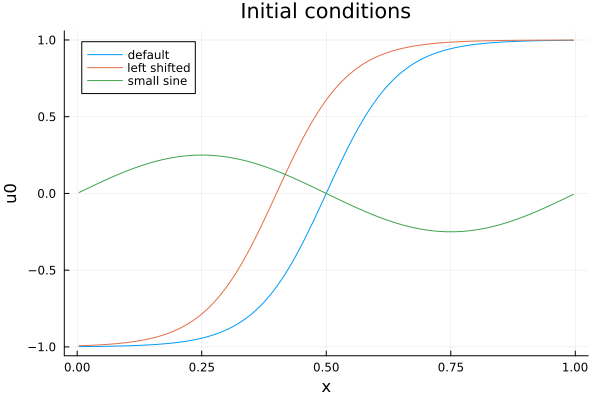

In [25]:
plot_initial_conditions(initial_condition_examples; N, L, ε2, dimension, boundary_condition)

## Run FOM, Build ROM, Run ROM

In [26]:
fom = run_fom_reference(; N, L, ε2, k, tspan, reference_dt_factor, u0, dimension, boundary_condition)
rom = build_stability_rom(fom, r, m; N_obs, h, seed)
rom_run = run_stability_rom(fom, rom);

Reference solve: dimension=1, boundary_condition=homogeneous_dirichlet, N=256, state_length=256, Δx=0.0038910505836575876, Δt=0.0003785068661145513, saved_times=500


## Singular-Value Capture

In [27]:
capture_table(fom; rs=[2, 4, 8, 10, 15, 20], ms=[2, 4, 8, 10, 15, 20])

36-element Vector{NamedTuple}:
 (m = 2, r = 2, state_capture = 0.9995750685967408, nonlinear_capture = 0.9947369341487972)
 (m = 4, r = 2, state_capture = 0.9995750685967408, nonlinear_capture = 0.9996818891647649)
 (m = 8, r = 2, state_capture = 0.9995750685967408, nonlinear_capture = 0.999997543995517)
 (m = 10, r = 2, state_capture = 0.9995750685967408, nonlinear_capture = 0.9999998934724468)
 (m = 15, r = 2, state_capture = 0.9995750685967408, nonlinear_capture = 0.9999999999930691)
 (m = 20, r = 2, state_capture = 0.9995750685967408, nonlinear_capture = 0.9999999999999998)
 (m = 2, r = 4, state_capture = 0.9999825580845881, nonlinear_capture = 0.9947369341487972)
 (m = 4, r = 4, state_capture = 0.9999825580845881, nonlinear_capture = 0.9996818891647649)
 (m = 8, r = 4, state_capture = 0.9999825580845881, nonlinear_capture = 0.999997543995517)
 (m = 10, r = 4, state_capture = 0.9999825580845881, nonlinear_capture = 0.9999998934724468)
 ⋮
 (m = 10, r = 15, state_capture = 0.99999999

## Trajectory

┌ Info: Saved animation to /Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/Research_Code/Optimization/Local/rom_stability_gifs/fom_reference.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156
┌ Info: Saved animation to /Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/Research_Code/Optimization/Local/rom_stability_gifs/fom_rom_overlay.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156



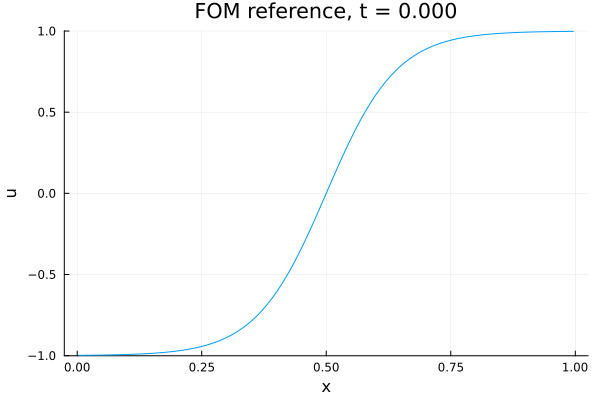


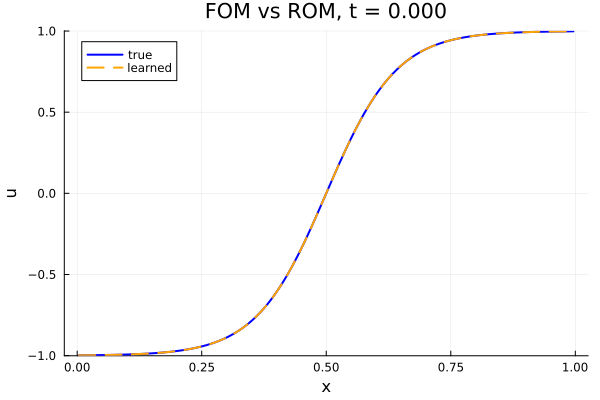

(fom_path = "/Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/Research_Code/Optimization/Local/rom_stability_gifs/fom_reference.gif", overlay_path = "/Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven/Research_Code/Optimization/Local/rom_stability_gifs/fom_rom_overlay.gif")

In [28]:
trajectory_gifs(fom, rom_run; max_frames=120, fps=15)

## Modes

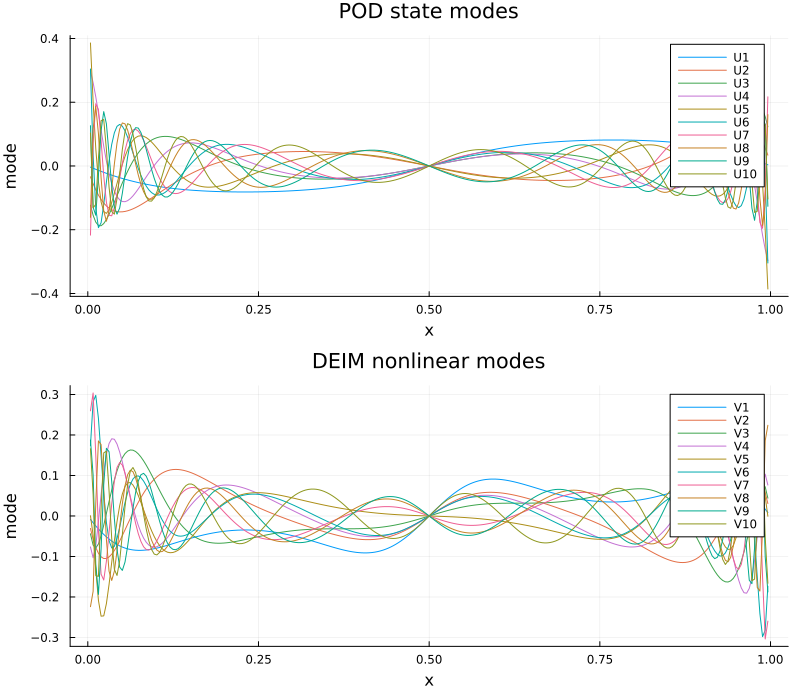

In [31]:
plot_modes(fom, rom, n_state=10,n_deim=10)